# Optical Flow-Based Frame Selection Demo

This notebook demonstrates how to use the `OpticalFlowFrameSelector` for intelligent video frame decimation and selection. The approach is based on VGGT-SLAM's keyframe selection strategy, combining:

1. **Motion-based selection**: Using Lucas-Kanade optical flow to detect camera motion
2. **Coverage-based selection**: Ensuring visual diversity and spatial coverage
3. **Adaptive thresholding**: Auto-adjusting parameters based on video statistics

This is particularly useful for preprocessing drone footage or other videos for 3D reconstruction tasks.

## About This Notebook

This notebook demonstrates the **`optical_flow` module** - a comprehensive toolkit for intelligent video frame selection using optical flow analysis.

### Quick Start

```python
from optical_flow import OpticalFlowFrameSelector

# Create selector
selector = OpticalFlowFrameSelector(min_disparity=60.0)

# Process video
selected_indices, metrics = selector.process_video('video.mp4')
```

### Module Structure

The `optical_flow.py` module provides:
- **`OpticalFlowFrameSelector`** - Main frame selection class
- **Video utilities** - Rotation detection, frame loading
- **Metrics extraction** - `extract_metrics()` for analysis
- **Visualization** - Flow visualization, summary plots
- **Export utilities** - Save indices, create copy scripts

All functions are importable and reusable in your own projects!

In [ ]:
import sys
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import Image, display

from collab_splats.wrapper import Splatter

# Import optical flow module
from optical_flow import (
    OpticalFlowFrameSelector,
    visualize_optical_flow,
    visualize_flow_between_frames,
    create_selection_summary_plot,
    create_configuration_comparison_plot,
    test_parameter_configuration,
    extract_metrics,
    get_video_rotation,
    rotate_frame,
    load_frame,
)

# Set up nice plotting defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Imports successful!")

## 1. Understanding the Algorithm

### How VGGT-SLAM Frame Selection Works

The VGGT-SLAM paper uses optical flow to select keyframes:

```python
# From VGGT-SLAM main.py
for image_name in tqdm(image_names):
    if use_optical_flow_downsample:
        img = cv2.imread(image_name)
        enough_disparity = solver.flow_tracker.compute_disparity(
            img, args.min_disparity, args.vis_flow
        )
        if enough_disparity:
            image_names_subset.append(image_name)
```

**Key steps:**
1. Detect good features to track (Shi-Tomasi corners)
2. Track features using Lucas-Kanade pyramidal optical flow
3. Compute mean displacement (disparity) of tracked points
4. Select frame if disparity > threshold (default: 50 pixels)

### Our Enhancements for Drone Footage

We extend this with:
- **Rotation detection**: Detect camera rotation (important for drones)
- **Coverage metrics**: Histogram similarity to avoid redundant frames
- **Adaptive thresholding**: Auto-adjust based on video motion statistics
- **Weighted scoring**: Combine motion and coverage with configurable weights

---

## How Frame Selection Works: Step-by-Step

### 1. Feature Detection (Shi-Tomasi Corner Detector)
For each frame, we first detect "good features to track" - strong corners that are easy to follow between frames:
```python
pts = cv2.goodFeaturesToTrack(gray_image, maxCorners=1000, qualityLevel=0.01, minDistance=8)
```
This finds up to 1000 corner points distributed across the image.

### 2. Optical Flow Tracking (Lucas-Kanade)
We track how these feature points move from the previous keyframe to the current frame:
```python
curr_pts, status, error = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None)
```
This gives us correspondences: where each point in the previous frame moved to in the current frame.

### 3. Motion Analysis
We compute two types of motion:

**A. Translation (Disparity):**
- Measures how far features moved in pixels
- `disparity = mean(||curr_pt - prev_pt||)` for all tracked points
- High disparity = camera moved or scene changed significantly

**B. Rotation:**
- Estimates camera rotation using affine transformation
- Extracts rotation angle from the transformation matrix
- Important for drones that often rotate in place

### 4. Coverage Analysis
To avoid selecting visually similar frames, we compute:

**Histogram Similarity:**
- Compare intensity histograms between current frame and last keyframe
- High similarity (>0.85) = frames look very similar = redundant
- Low similarity = frames look different = good for coverage

### 5. Scoring and Selection
Each frame gets a combined score:

```
motion_score = max(disparity/threshold, rotation/rotation_threshold)
coverage_score = 1 - histogram_similarity

combined_score = motion_weight × motion_score + coverage_weight × coverage_score
```

**Frame is selected if:** `combined_score >= selection_threshold` (default: 0.5)

### 6. Keyframe Update
When a frame is selected:
- It becomes the new reference keyframe
- New features are detected in this frame
- Future frames are compared against this keyframe

This ensures selected frames are well-distributed and non-redundant.

---

### Why This Matters for 3D Reconstruction

**Good frame selection is critical for:**
- **COLMAP**: Needs sufficient baseline (motion) between images for triangulation
- **NeRF/Gaussian Splatting**: Needs diverse viewpoints to cover the scene
- **SLAM**: Needs keyframes with enough motion to update the map

**Our approach balances:**
- Enough motion between frames (avoid near-duplicates)
- Enough coverage (capture different parts of the scene)
- Not too sparse (maintain temporal continuity for matching)

## 2. Basic Usage Example

Let's start with a simple example using default parameters.

In [28]:
# Create a selector with default parameters
selector = OpticalFlowFrameSelector(
    min_disparity=60.0,         # Minimum pixel displacement for keyframe
    motion_weight=0.5,          # 60% weight on motion
    coverage_weight=0.5,        # 40% weight on visual diversity
    rotation_threshold=3.0,
    adaptive_threshold=True,    # Auto-adjust threshold
    verbose=True
)

print(f"Selector initialized:")
print(f"  Motion weight: {selector.motion_weight:.1%}")
print(f"  Coverage weight: {selector.coverage_weight:.1%}")
print(f"  Min disparity: {selector.min_disparity} pixels")
print(f"  Rotation threshold: {selector.rotation_threshold} degrees")

Selector initialized:
  Motion weight: 50.0%
  Coverage weight: 50.0%
  Min disparity: 60.0 pixels
  Rotation threshold: 3.0 degrees


## 3. Process a Video File

### Option A: If you have a video file

In [29]:
# Configuration paths
config_dir = Path("/workspace/collab-splats/docs/splats/configs")
dataset_name = "birds_date-02062024_video-C0043" #"bicycle_mapanything"

print(f"Loading configuration: {dataset_name}")
print(f"Config directory: {config_dir}")

# Load the splatter configuration
splatter = Splatter.from_config_file(
    dataset=dataset_name,
    config_dir=config_dir,
)

print(f"\n" + "="*70)
print("Configuration Loaded")
print("="*70)
print(f"Dataset: {splatter.config['file_path']}")
print(f"Method: {splatter.config['method']}")
print(f"Input type: {splatter.config['input_type']}")
print(f"Output: {splatter.config['output_path']}")
print("="*70)

Loading configuration: birds_date-02062024_video-C0043
Config directory: /workspace/collab-splats/docs/splats/configs
✓ Valid video file with 2388 frames

Configuration Loaded
Dataset: /workspace/fieldwork-data/birds/2024-02-06/SplatsSD/C0043.MP4
Method: rade-features
Input type: video
Output: /workspace/fieldwork-data/birds/2024-02-06/environment/C0043


In [ ]:
# Example: Process a video file
# Uncomment and modify the path to your video

video_path = splatter.config['file_path']

# Detect video rotation from metadata
video_rotation = get_video_rotation(video_path)
if video_rotation is not None:
    rotation_degrees = {
        cv2.ROTATE_90_CLOCKWISE: 90,
        cv2.ROTATE_180: 180,
        cv2.ROTATE_90_COUNTERCLOCKWISE: 270
    }.get(video_rotation, 0)
    print(f"Detected video rotation: {rotation_degrees}° (will be corrected in visualizations)")
else:
    print("No rotation metadata detected")

selected_indices, metrics = selector.process_video(
    video_path=video_path,
    max_frames=None,              # Process all frames (or set a limit for testing)
    selection_threshold=0.5,      # Threshold for combined score
    save_selected_frames=True,    # Save selected frames to disk
    output_dir=None,              # Auto-generate output directory
)

print(f"\nProcessed {metrics['total_frames']} frames")
print(f"Selected {metrics['selected_frames']} frames ({metrics['selection_rate']:.1%})")
print(f"Selected frame indices: {selected_indices[:10]}...")  # Show first 10

Detected video rotation: 90° (will be corrected in visualizations)


## 4. Visualize Selection Metrics

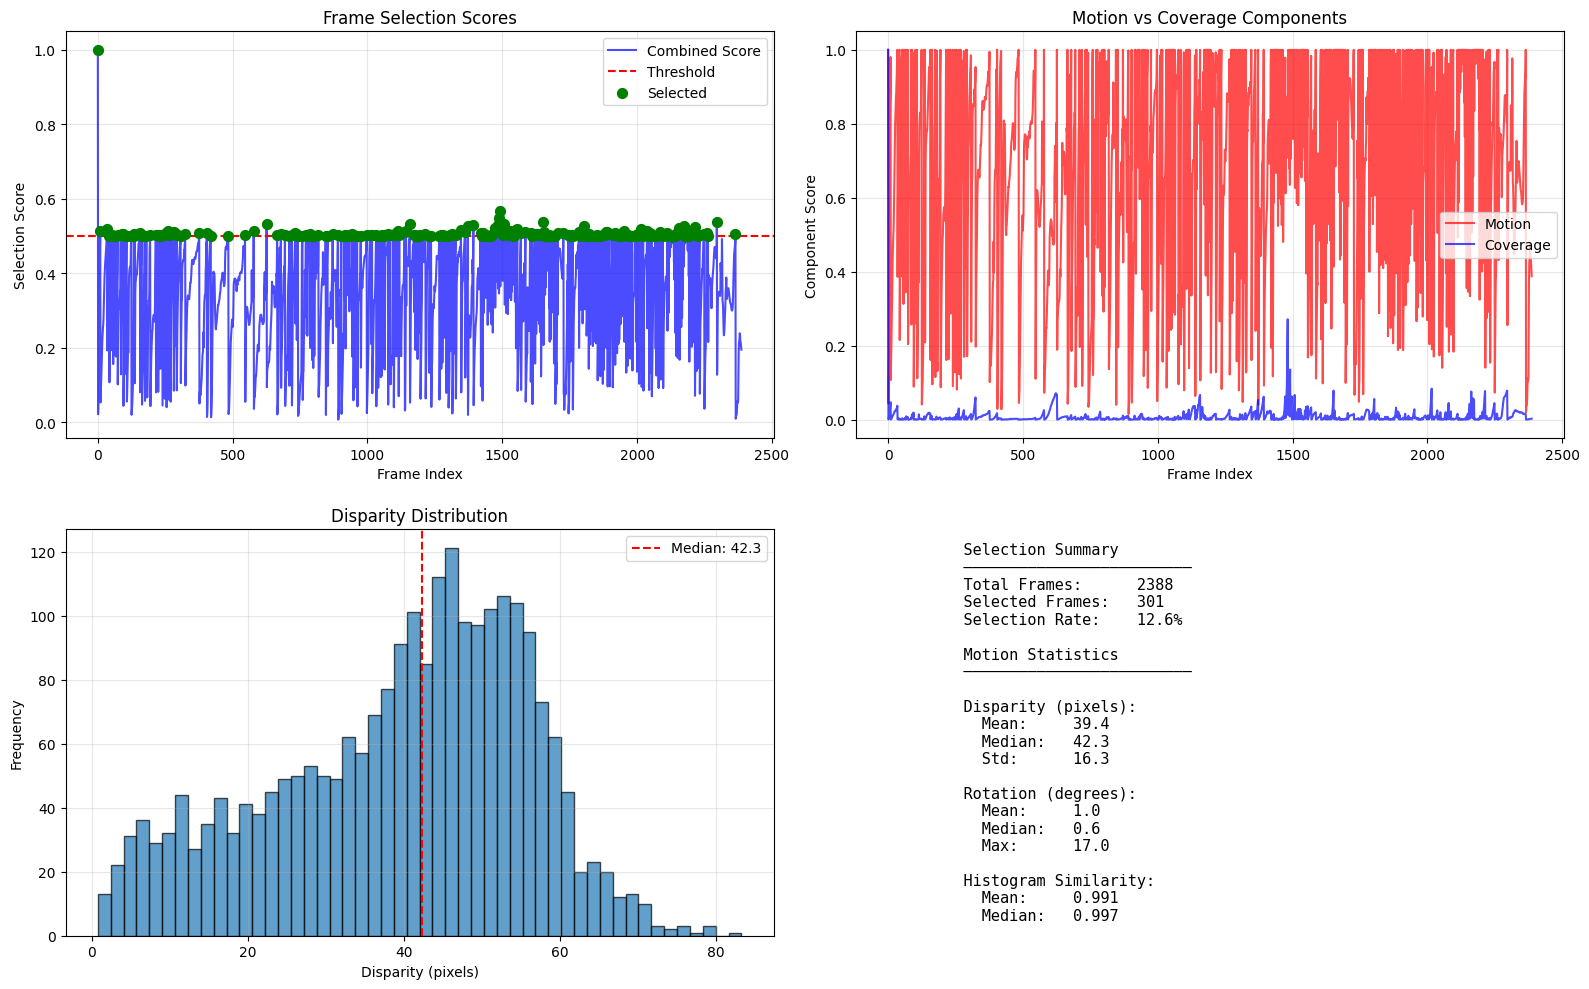


Interpretation:
  - Top-left: Combined selection scores over time
  - Top-right: Motion vs coverage component contributions
  - Bottom-left: Distribution of displacement magnitudes
  - Bottom-right: Summary statistics


In [17]:
# Create comprehensive summary plot
fig = create_selection_summary_plot(metrics, figsize=(16, 10))
plt.show()

print("\nInterpretation:")
print("  - Top-left: Combined selection scores over time")
print("  - Top-right: Motion vs coverage component contributions")
print("  - Bottom-left: Distribution of displacement magnitudes")
print("  - Bottom-right: Summary statistics")

## 5. Detailed Disparity Analysis and Diagnostics

Let's dive deeper into the optical flow disparities across the video to understand motion patterns and frame selection behavior.

In [ ]:
# Extract metrics for plotting and analysis
plot_data = extract_metrics(metrics)

print(f"Extracted data:")
print(f"  Total frames processed: {len(plot_data['combined_scores'])}")
print(f"  Disparity values (stats): {len(plot_data['disparities'])}")
print(f"  Note: First frame is always selected (no disparity computed)")
print(f"\nData shapes:")
for key, val in plot_data.items():
    print(f"  {key}: {val.shape}")

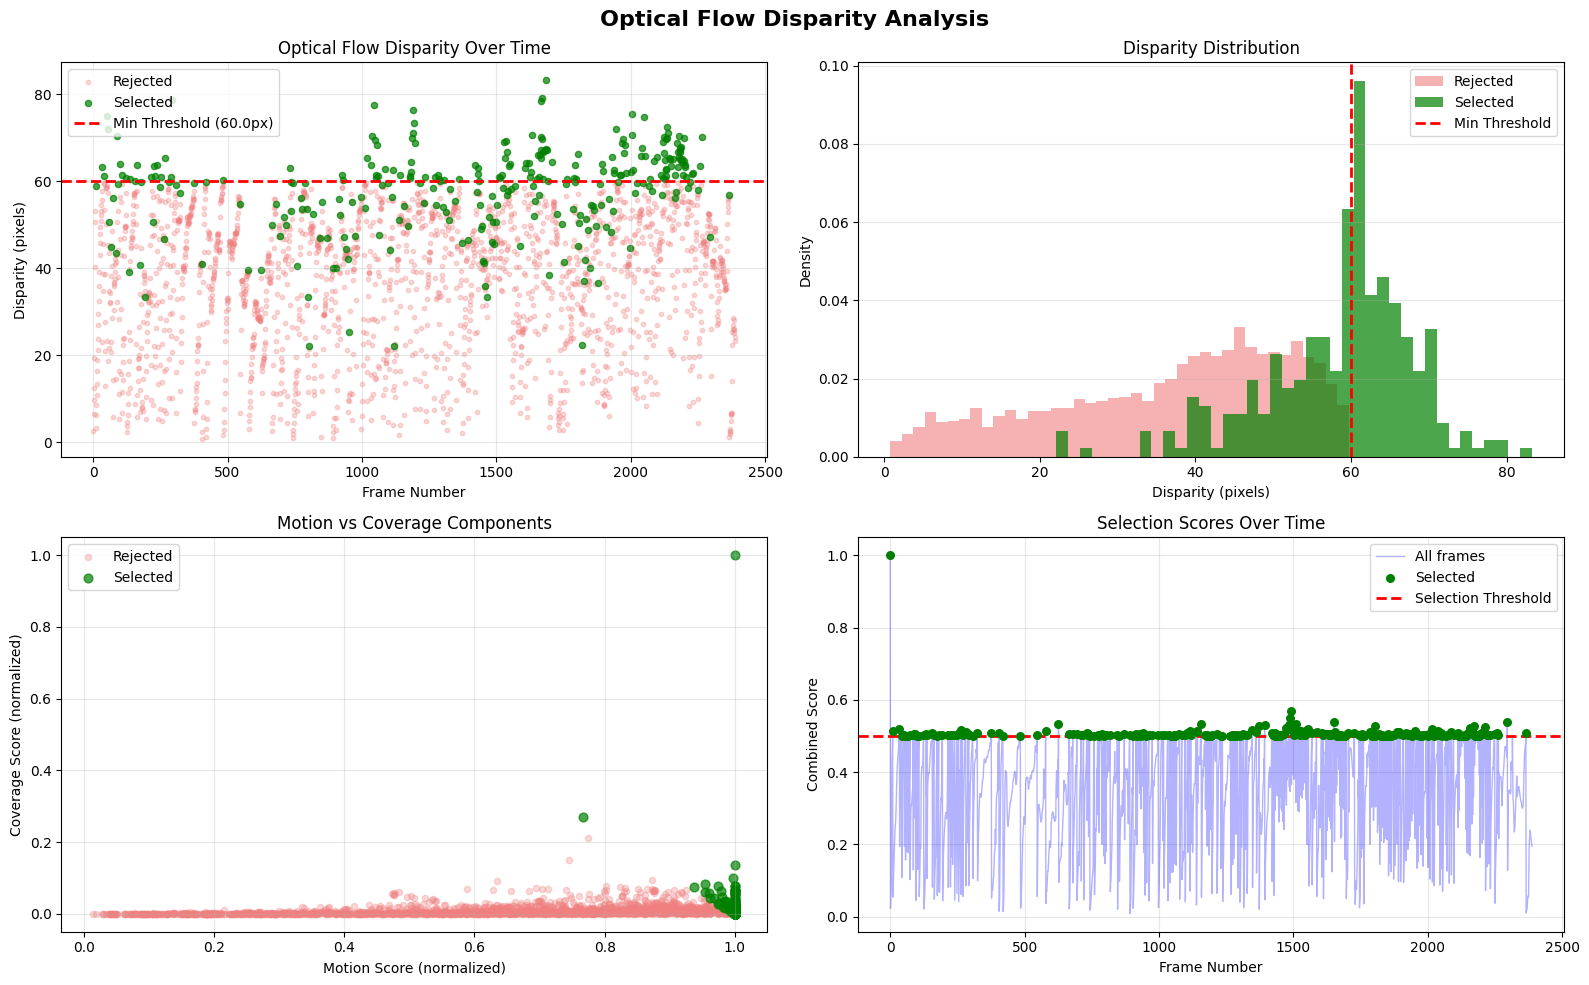


DISPARITY ANALYSIS SUMMARY
Selection rate: 12.6%
Selected: 301 / 2388 frames

Disparity statistics (in pixels):
  All frames    - Mean: 39.4px, Median: 42.3px, Max: 83.2px
  Selected      - Mean: 58.5px
  Rejected      - Mean: 36.7px
  Min threshold: 60.0px

Rotation statistics (in degrees):
  Mean rotation: 1.02°, Max rotation: 16.97°
  Rotation threshold: 3.0°


In [12]:
# Create disparity analysis visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Optical Flow Disparity Analysis', fontsize=16, fontweight='bold')

# Note: disparities array starts from frame 1 (first frame has no previous frame to compare)
# So we need to offset our frame numbers by 1
total_frames = len(plot_data['combined_scores'])
disparity_frame_numbers = np.arange(1, len(plot_data['disparities']) + 1)  # Start from frame 1
all_frame_numbers = np.arange(total_frames)

# Create mask for which frames are selected
selected_mask_all = np.array([i in selected_indices for i in all_frame_numbers])

# For disparity plots, we need a mask that aligns with disparity data (excluding frame 0)
selected_mask_disp = np.array([i in selected_indices for i in disparity_frame_numbers])

# 1. Disparity timeline
ax1 = axes[0, 0]
ax1.scatter(disparity_frame_numbers[~selected_mask_disp], plot_data['disparities'][~selected_mask_disp], 
           c='lightcoral', alpha=0.3, s=10, label='Rejected')
ax1.scatter(disparity_frame_numbers[selected_mask_disp], plot_data['disparities'][selected_mask_disp], 
           c='green', alpha=0.7, s=20, label='Selected')
ax1.axhline(y=selector.min_disparity, color='red', linestyle='--', linewidth=2, 
           label=f'Min Threshold ({selector.min_disparity}px)')
ax1.set_xlabel('Frame Number')
ax1.set_ylabel('Disparity (pixels)')
ax1.set_title('Optical Flow Disparity Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Disparity distribution
ax2 = axes[0, 1]
ax2.hist(plot_data['disparities'][~selected_mask_disp], bins=40, alpha=0.6, 
        color='lightcoral', label='Rejected', density=True)
ax2.hist(plot_data['disparities'][selected_mask_disp], bins=40, alpha=0.7, 
        color='green', label='Selected', density=True)
ax2.axvline(x=selector.min_disparity, color='red', linestyle='--', linewidth=2, 
           label=f'Min Threshold')
ax2.set_xlabel('Disparity (pixels)')
ax2.set_ylabel('Density')
ax2.set_title('Disparity Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Motion vs Coverage scatter
ax3 = axes[1, 0]
ax3.scatter(plot_data['motion_scores'][~selected_mask_all], 
           plot_data['coverage_scores'][~selected_mask_all],
           c='lightcoral', alpha=0.3, s=20, label='Rejected')
ax3.scatter(plot_data['motion_scores'][selected_mask_all], 
           plot_data['coverage_scores'][selected_mask_all],
           c='green', alpha=0.7, s=40, label='Selected')
ax3.set_xlabel('Motion Score (normalized)')
ax3.set_ylabel('Coverage Score (normalized)')
ax3.set_title('Motion vs Coverage Components')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Combined score timeline
ax4 = axes[1, 1]
ax4.plot(all_frame_numbers, plot_data['combined_scores'], 'b-', alpha=0.3, linewidth=1, label='All frames')
ax4.scatter(all_frame_numbers[selected_mask_all], plot_data['combined_scores'][selected_mask_all],
           c='green', s=30, label='Selected', zorder=5)
ax4.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Selection Threshold')
ax4.set_xlabel('Frame Number')
ax4.set_ylabel('Combined Score')
ax4.set_title('Selection Scores Over Time')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n{'='*70}")
print(f"DISPARITY ANALYSIS SUMMARY")
print(f"{'='*70}")
print(f"Selection rate: {metrics['selection_rate']:.1%}")
print(f"Selected: {metrics['selected_frames']} / {metrics['total_frames']} frames")
print(f"\nDisparity statistics (in pixels):")
print(f"  All frames    - Mean: {plot_data['disparities'].mean():.1f}px, "
      f"Median: {np.median(plot_data['disparities']):.1f}px, "
      f"Max: {plot_data['disparities'].max():.1f}px")
if len(plot_data['disparities'][selected_mask_disp]) > 0:
    print(f"  Selected      - Mean: {plot_data['disparities'][selected_mask_disp].mean():.1f}px")
if len(plot_data['disparities'][~selected_mask_disp]) > 0:
    print(f"  Rejected      - Mean: {plot_data['disparities'][~selected_mask_disp].mean():.1f}px")
print(f"  Min threshold: {selector.min_disparity}px")
print(f"\nRotation statistics (in degrees):")
print(f"  Mean rotation: {plot_data['rotations'].mean():.2f}°, "
      f"Max rotation: {plot_data['rotations'].max():.2f}°")
print(f"  Rotation threshold: {selector.rotation_threshold}°")
print(f"{'='*70}")

## 6. Visualize Optical Flow

Let's visualize the optical flow between consecutive frames to understand what's happening.

In [ ]:
# Load sample frames from the video for visualization
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Sample frames at different points in the video
sample_points = [
    (50, 55, "Early section"),
    (500, 505, "Mid-early section"),
    (1000, 1005, "Middle section"),
    (1500, 1505, "Mid-late section"),
    (2000, 2005, "Late section"),
    (2300, 2305, "End section"),
]

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Optical Flow Visualization at Different Video Sections', fontsize=16, fontweight='bold')

for idx, (f1, f2, label) in enumerate(sample_points):
    if idx >= 6:  # Only plot 6 samples
        break
    
    ax = axes[idx // 3, idx % 3]
    
    frame1 = load_frame(cap, f1)
    frame2 = load_frame(cap, f2)
    
    flow_vis, disparity, num_features = visualize_flow_between_frames(frame1, frame2, selector)
    
    if flow_vis is not None:
        # Apply rotation correction before displaying
        flow_vis_display = rotate_frame(flow_vis, video_rotation)
        ax.imshow(cv2.cvtColor(flow_vis_display, cv2.COLOR_BGR2RGB))
        
        # Determine if frame would be selected
        selected = "✓ SELECTED" if disparity >= selector.min_disparity else "✗ REJECTED"
        color = 'green' if disparity >= selector.min_disparity else 'red'
        
        ax.set_title(f"{label}\nFrames {f1}→{f2} | Disparity: {disparity:.1f}px | Features: {num_features}\n{selected}", 
                    fontsize=10, color=color, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No features detected', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{label} (No data)", fontsize=10)
    
    ax.axis('off')

cap.release()
plt.tight_layout()
plt.show()

print("\nFlow visualization legend:")
print("  • Flow vectors shown as arrows from previous to current position")
print("  • Arrow color indicates motion magnitude:")
print("    - Blue: Small motion (< 20px)")
print("    - Green: Medium motion (20-50px)")
print("    - Yellow: Large motion (50-100px)")
print("    - Red: Very large motion (> 100px)")
print(f"\n  • Frames with disparity >= {selector.min_disparity}px are SELECTED")
print(f"  • Frames with disparity < {selector.min_disparity}px are REJECTED")

## 7. Compare Different Parameter Settings

Let's see how different parameter configurations affect frame selection.

In [ ]:
# Test different configurations on a sample of frames from the video
cap = cv2.VideoCapture(video_path)
sample_frames = []
sample_frame_indices = list(range(0, min(2388, total_frames), 25))  # Sample every 25th frame

print(f"Loading {len(sample_frame_indices)} sample frames for configuration testing...")
for frame_idx in sample_frame_indices:
    frame = load_frame(cap, frame_idx)
    if frame is not None:
        sample_frames.append(frame)
cap.release()

print(f"Loaded {len(sample_frames)} frames\n")

# Define configurations to test
configs = {
    "Conservative (high threshold)": {
        "min_disparity": 80, 
        "motion_weight": 0.8, 
        "coverage_weight": 0.2
    },
    "Balanced (default)": {
        "min_disparity": 60, 
        "motion_weight": 0.5, 
        "coverage_weight": 0.5
    },
    "Aggressive (low threshold)": {
        "min_disparity": 30, 
        "motion_weight": 0.5, 
        "coverage_weight": 0.5
    },
    "Coverage-focused": {
        "min_disparity": 50, 
        "motion_weight": 0.3, 
        "coverage_weight": 0.7
    },
}

# Test each configuration
results = {}
print("Testing different configurations on sample frames...\n")

for config_name, params in configs.items():
    result = test_parameter_configuration(sample_frames, config_name, **params)
    results[config_name] = result
    print(f"{config_name}:")
    print(f"  Parameters: min_disparity={params['min_disparity']}, "
          f"motion_weight={params['motion_weight']}, coverage_weight={params['coverage_weight']}")
    print(f"  Selected {len(result['selected'])}/{len(sample_frames)} frames "
          f"({len(result['selected'])/len(sample_frames)*100:.1f}%)")
    print(f"  Mean disparity: {np.mean(result['disparities']):.1f}px")
    print(f"  Selected frame indices: {result['selected'][:10]}"
          f"{'...' if len(result['selected']) > 10 else ''}\n")

# Create comprehensive comparison visualization
fig = create_configuration_comparison_plot(results, len(sample_frames), configs, figsize=(16, 12))
plt.show()

print("\n" + "="*70)
print("Configuration Recommendations:")
print("="*70)
print("• Conservative: Use when you want only the most distinct frames")
print("• Balanced: Good default for most scenarios")
print("• Aggressive: Use when you want denser frame coverage")
print("• Coverage-focused: Prioritizes visual diversity over motion")
print("="*70)

## 8. Visualize Selected Frames

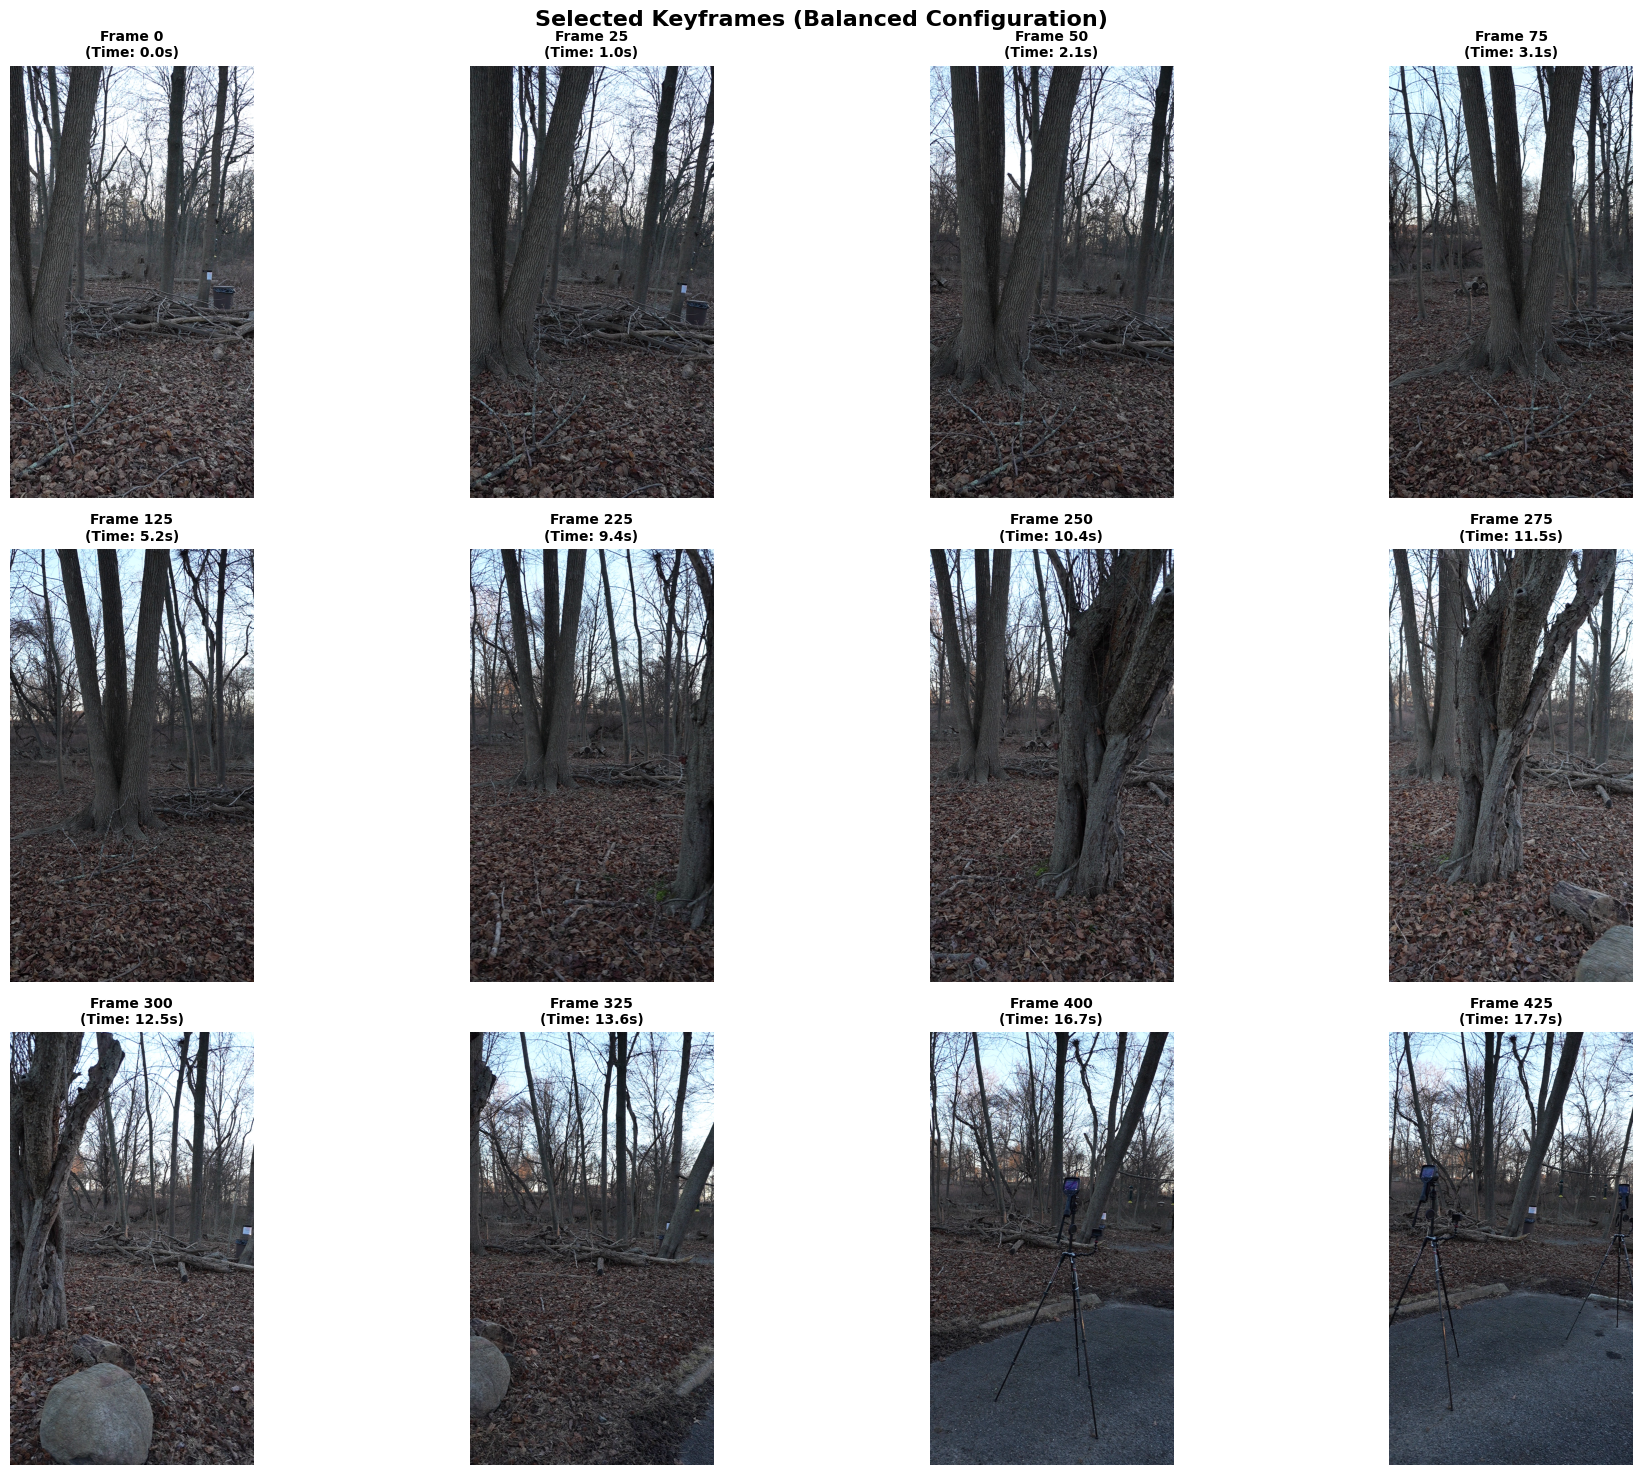


Showing 12 selected frames out of 96 sampled frames
Total frames in video: 2388
Actual video frame indices shown: [0, 25, 50, 75, 125, 225, 250, 275, 300, 325, 400, 425]

These frames represent diverse viewpoints/motions from the video,
suitable for 3D reconstruction or scene understanding tasks.


In [20]:
# Visualize selected frames from the balanced configuration
selected_frame_indices = results["Balanced (default)"]['selected']

# Load selected frames from video
cap = cv2.VideoCapture(video_path)
selected_frames_to_show = []

# Map sample indices back to actual video frame indices
actual_selected_indices = [sample_frame_indices[i] for i in selected_frame_indices[:12]]

for frame_idx in actual_selected_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if ret:
        # Apply rotation correction
        frame_display = rotate_frame(frame, video_rotation)
        selected_frames_to_show.append((frame_idx, frame_display))

cap.release()

# Show selected frames in a grid
num_show = min(12, len(selected_frames_to_show))
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Selected Keyframes (Balanced Configuration)', fontsize=16, fontweight='bold')

for i in range(num_show):
    ax = axes[i // 4, i % 4]
    frame_idx, frame = selected_frames_to_show[i]
    
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {frame_idx}\n(Time: {frame_idx/23.98:.1f}s)", fontsize=10, fontweight='bold')
    ax.axis('off')

# Hide extra subplots if we have fewer than 12 frames
for i in range(num_show, 12):
    axes[i // 4, i % 4].axis('off')

plt.tight_layout()
plt.show()

print(f"\nShowing {num_show} selected frames out of {len(sample_frames)} sampled frames")
print(f"Total frames in video: {total_frames}")
print(f"Actual video frame indices shown: {actual_selected_indices}")
print(f"\nThese frames represent diverse viewpoints/motions from the video,")
print(f"suitable for 3D reconstruction or scene understanding tasks.")

## 9. Recommendations for Real Usage

Based on the analysis, here are recommendations for different scenarios:

### For Drone Footage (Outdoor, Fast Motion)
```python
selector = OpticalFlowFrameSelector(
    min_disparity=40.0,          # Lower threshold for faster motion
    motion_weight=0.6,           # Prioritize motion
    coverage_weight=0.4,         # Some coverage diversity
    rotation_threshold=5.0,      # Detect rotation (important for drones)
    adaptive_threshold=True,     # Auto-adjust
    verbose=True
)
```

### For Indoor/Handheld (Slow, Controlled Motion)
```python
selector = OpticalFlowFrameSelector(
    min_disparity=60.0,          # Higher threshold
    motion_weight=0.5,           # Balance motion and coverage
    coverage_weight=0.5,
    rotation_threshold=3.0,      # Lower rotation threshold
    adaptive_threshold=True,
    verbose=True
)
```

### For Maximum Coverage (Reconstruction)
```python
selector = OpticalFlowFrameSelector(
    min_disparity=50.0,
    motion_weight=0.3,           # De-emphasize motion
    coverage_weight=0.7,         # Prioritize diversity
    histogram_similarity_threshold=0.80,  # Require more visual difference
    adaptive_threshold=True,
    verbose=True
)
```

### Tuning Tips
1. **Start with defaults** and observe the selection rate
2. If selecting **too many frames**: Increase `min_disparity` or `selection_threshold`
3. If selecting **too few frames**: Decrease `min_disparity` or increase `coverage_weight`
4. For **drone rotation**: Ensure `rotation_threshold` is reasonable (3-8 degrees)
5. Use **adaptive_threshold=True** to get suggestions for optimal `min_disparity`

## 10. Export Selected Frames for 3D Reconstruction

After selection, you can use the selected frames with your reconstruction pipeline.

In [ ]:
# Import export utilities from optical_flow module
from optical_flow import save_selected_indices, create_copy_script

# Example usage for saving indices:
# save_selected_indices(selected_indices, "selected_frames.txt")

# Example usage for creating a copy script:
# If you have a list of image paths:
# image_paths = [Path(f"frame_{i:06d}.jpg") for i in selected_indices]
# create_copy_script(image_paths, selected_indices, "copy_selected.sh")

print("Export utilities are available:")
print("  • save_selected_indices() - Save frame indices to text file")
print("  • create_copy_script() - Generate bash script to copy selected frames")
print("\nYou can also directly access saved frames at:")
print(f"  {Path(video_path).parent / Path(video_path).stem}_selected/")

## Summary

This notebook demonstrated:

1. ✅ **How VGGT-SLAM's optical flow approach works** (Lucas-Kanade + disparity threshold)
2. ✅ **Our enhancements for drone footage** (rotation detection, coverage metrics, adaptive thresholding)
3. ✅ **Basic usage** with `OpticalFlowFrameSelector`
4. ✅ **Processing videos and image directories**
5. ✅ **Comprehensive visualizations** (scores, flow vectors, metrics)
6. ✅ **Parameter comparison** for different use cases
7. ✅ **Practical recommendations** for tuning

### Next Steps

- Apply this to your own drone footage or video sequences
- Experiment with different parameter configurations
- Integrate with your 3D reconstruction pipeline (COLMAP, NeRF, Gaussian Splatting, etc.)
- Use the adaptive threshold suggestions to optimize for your specific data

### References

- VGGT-SLAM: https://github.com/MIT-SPARK/VGGT-SLAM
- Lucas-Kanade Optical Flow: https://docs.opencv.org/4.x/d4/dee/tutorial_optical_flow.html
- Good Features to Track: https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html